# Part 3: Advanced Text Processing - LDA and BERTopic Topic Modeling

In [1]:
from spacy import displacy
from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.feature_extraction.text import CountVectorizer
import pyLDAvis
import pyLDAvis.gensim_models

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-dark') 

In [3]:
OUTPUT_DIR = 'outputs'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

In [4]:
import spacy
from tqdm import tqdm
from collections import Counter
nlp = spacy.load("en_core_web_sm")

In [5]:
sou = pd.read_csv('data/SOTU.csv')
sou

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169
...,...,...,...,...
241,George Washington,1791.0,\nFellow-Citizens of the Senate and House of R...,2264
242,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
243,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
244,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069


# LDA

In [6]:
def preprocess_text(text): 
    doc = nlp(text) 
    return [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 3]

In [7]:
# Process all texts - note this takes ~ 5 minutes to run
processed_docs = sou['Text'].apply(preprocess_text)

This part was doing the processing for all texts.

## Build dictionary from processed_docs, which is a list of tokens extracted from our speeches

In [8]:
dictionary = Dictionary(processed_docs) 
dictionary.filter_extremes(no_below=5, no_above=0.5) 
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

## Train LDA model with 18 topics

In [9]:
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=18, random_state=42, passes=10)

## Print the top 10 words for each topic

In [10]:
print("\n--- LDA Topics ---") 
for idx, topic in lda_model.print_topics(-1): 
    print(f"Topic: {idx} \nWords: {topic}\n")


--- LDA Topics ---
Topic: 0 
Words: 0.004*"cent" + 0.004*"june" + 0.004*"gold" + 0.003*"island" + 0.003*"silver" + 0.003*"bond" + 0.003*"method" + 0.003*"convention" + 0.003*"indian" + 0.003*"note"

Topic: 1 
Words: 0.008*"depression" + 0.007*"program" + 0.007*"recovery" + 0.006*"budget" + 0.006*"unemployment" + 0.006*"loan" + 0.006*"activity" + 0.006*"farm" + 0.005*"emergency" + 0.005*"cent"

Topic: 2 
Words: 0.008*"dictator" + 0.005*"expression" + 0.004*"british" + 0.004*"1914" + 0.003*"impressive" + 0.003*"actual" + 0.003*"revolution" + 0.003*"schedule" + 0.003*"continent" + 0.003*"partisanship"

Topic: 3 
Words: 0.008*"forest" + 0.007*"corporation" + 0.005*"judge" + 0.005*"wrong" + 0.005*"interstate" + 0.004*"employee" + 0.003*"bureau" + 0.003*"body" + 0.003*"mountain" + 0.003*"island"

Topic: 4 
Words: 0.017*"program" + 0.014*"soviet" + 0.009*"1980" + 0.009*"u.s." + 0.008*"area" + 0.007*"major" + 0.006*"goal" + 0.006*"commitment" + 0.006*"challenge" + 0.006*"nuclear"

Topic: 5 
W

These are the lists of the top 10 words for each topic and it shows interesting list of words in each topics. 

## Print the topic distribution for the first speech

In [12]:
lda_model[corpus][0]

[(11, np.float32(0.99942815))]

This is the topic distribution for the first speech and it is identifiying topic 11 with 99.942815%. 

## Make a visualization using pyLDAvis

In [14]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
filepath = os.path.join(OUTPUT_DIR, "lda-visualization.html")
pyLDAvis.save_html(vis, filepath)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.124490 -0.021460       1        1  25.617696
6     -0.177721  0.042077       2        1  19.986343
5      0.215260  0.071386       3        1   9.900826
7      0.135347 -0.070053       4        1   9.755965
8     -0.048065 -0.119211       5        1   7.287009
17    -0.174387  0.056450       6        1   5.732620
13    -0.173280  0.057692       7        1   5.116923
9     -0.065566 -0.065617       8        1   3.674026
11     0.221114  0.096518       9        1   3.312774
12     0.108985 -0.107040      10        1   3.207911
4      0.170987 -0.059934      11        1   2.417604
3     -0.048335 -0.061174      12        1   1.964417
1      0.001805 -0.137938      13        1   1.024425
14     0.149811  0.117592      14        1   0.773018
15    -0.097709  0.071397      15        1   0.174832
2     -0.030759  0.033480      16        1   0.045780
10    -0.027617  0.048256      17        1   0.003916
16    -0.035383  0.047579      18        1   0.003916, topic_info=           Term         Freq        Total Category  logprob  loglift
509     program  1272.000000  1272.000000  Default  30.0000  30.0000
978      mexico   852.000000   852.000000  Default  29.0000  29.0000
31    americans   990.000000   990.000000  Default  28.0000  28.0000
5330    article   492.000000   492.000000  Default  27.0000  27.0000
666     tonight   666.000000   666.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
3221     method     0.007818   526.095995  Topic18  -7.4658  -0.9690
664       today     0.007947   576.840799  Topic18  -7.4494  -1.0447
1148    appoint     0.007382   419.002720  Topic18  -7.5231  -0.7987
31    americans     0.008294   990.541445  Topic18  -7.4067  -1.5427
2624       cent     0.007440   614.012493  Topic18  -7.5154  -1.1731

[1282 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
4847      4  0.881709  --the
4847      8  0.080155  --the
3170      1  0.132809   11th
3170      2  0.079685   11th
3170      6  0.292179   11th
...     ...       ...    ...
744       9  0.116609  young
744      10  0.003239  young
744      11  0.016196  young
744      12  0.009717  young
744      14  0.009717  young

[5615 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 7, 6, 8, 9, 18, 14, 10, 12, 13, 5, 4, 2, 15, 16, 3, 11, 17])

This shows the visualization for intertopic distance map and top 30 most salient terms. It appears to me that program has the most overall term frequency. Furthermore, we can see some marginal topic distribution in the 5% to 10% in varies topics. 

# BERTopic

In [15]:
docs = sou['Text'].to_list()

## Train a BERTopic model with a min_topic_size of 3 Hint: use BERTopic to instantiate the model and specify min_topic_size in here. Actually fit the model using fit_transform, which docs passed into this.

In [16]:
topic_model = BERTopic(min_topic_size=3, verbose=True)
topics, probs = topic_model.fit_transform(docs)

2025-11-21 10:38:40,686 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

2025-11-21 10:38:54,646 - BERTopic - Embedding - Completed ✓
2025-11-21 10:38:54,647 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-21 10:39:11,673 - BERTopic - Dimensionality - Completed ✓
2025-11-21 10:39:11,674 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-21 10:39:11,689 - BERTopic - Cluster - Completed ✓
2025-11-21 10:39:11,708 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-21 10:39:13,158 - BERTopic - Representation - Completed ✓


In [17]:
vector = CountVectorizer(stop_words='english')
topic_model.update_topics(docs, vectorizer_model=vector)

This one removes all the stop words from 'english'. In addition, we used vectorizer to remove all the stop words from each topics inside docs. 

## Output the top 10 words for each topic.

In [19]:
topicinfo = topic_model.get_topic_info()
df_filepath = os.path.join(OUTPUT_DIR, "topicinfo.csv")
topicinfo.to_csv(df_filepath, index=False)
topicinfo

,Topic,Count,Name,Representation,Representative_Docs
0,-1,70,-1_government_states_united_congress,"[government, states, united, congress, year, p...",[\nJump toPart II |Part III\nPart 1. [On Our F...
1,0,29,0_world_people_new_years,"[world, people, new, years, america, american,...","[\nMr. Speaker, Mr. President, my colleagues i..."
2,1,14,1_states_government_united_public,"[states, government, united, public, mexico, c...",[\nFellow-Citizens of the Senate and House of ...
3,2,11,2_government_work_public_congress,"[government, work, public, congress, great, la...",[\nTo the Senate and House of Representatives:...
4,3,10,3_world_peace_nations_soviet,"[world, peace, nations, soviet, economic, nati...","[\nMr. President, Mr. Speaker, Members of the ..."
5,4,10,4_states_united_british_war,"[states, united, british, war, great, enemy, c...",[\nThe Senate and House of Representatives of ...
6,5,9,5_states_government_united_year,"[states, government, united, year, congress, g...",[\nFellow-Citizens of the Senate and House of ...
7,6,8,6_america_american_americans_going,"[america, american, americans, going, people, ...","[\nThe President. Madam Speaker, Mr. Vice Pres..."
8,7,8,7_world_free_nations_economic,"[world, free, nations, economic, great, war, p...","[\nMr. President, Mr. Speaker, and Members of ..."
9,8,8,8_government_states_law_united,"[government, states, law, united, congress, am...",[\nFellow-Citizens of the Senate and of the Ho...


Although, the representation is a little bit different from the inital notebook. However, there are some differences because BERTopic is random, which results in diffeerent outputs.  We can see in the dataset that the topic is ordered from increasing to decreasing in the number of count. The most count being topic -1 and the lowest being topic 22 and 23 with count 3.

## Output the topic distribution for the first speech

100%|██████████| 1/1 [00:15<00:00, 15.31s/it]


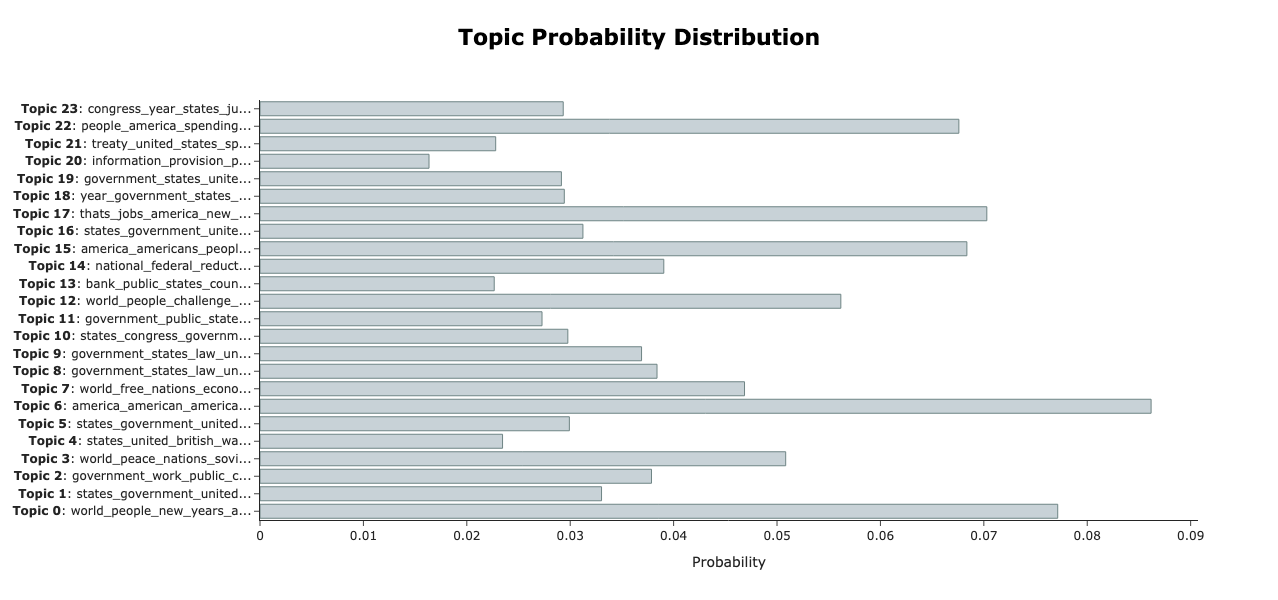

In [21]:
topic_distr, _ = topic_model.approximate_distribution(docs, min_similarity=0)
plot = topic_model.visualize_distribution(topic_distr[0])
filepath = os.path.join(OUTPUT_DIR, "BERTopic-plot.html")
plot.write_html(filepath)
plot

This is also similar to the above. The plot might differ from the initial plot. However, we can see that we can see every distribution in the plot. As we can see that topic 7 has the greatest probability in distribution of more than 0.08 and lowest being topic 20 with 0.02. 

## Make a visualization of the topics (see topic_model.visualize_topics())

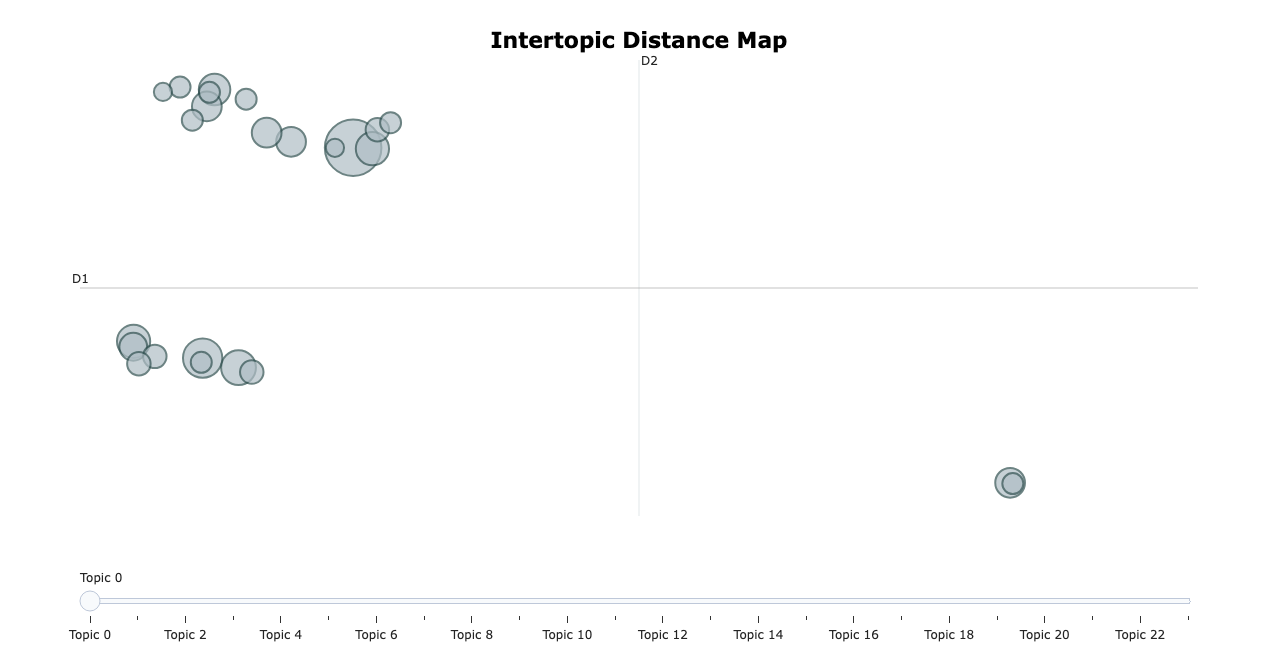

In [22]:
visualization = topic_model.visualize_topics()
fig_filepath = os.path.join(OUTPUT_DIR, "topics_visualization.html")
visualization.write_html(fig_filepath)
visualization

The visualization is the intertopic distnace map and we can see that there are four clusters, one in the fourth quadriant, two in the second, and another one in the third quadriant. We can see that marginal topic distribution is from 5% to 10% for everything. 